In [76]:
import os
import numpy as np
import pandas as pd
from matplotlib import rcParams

In [77]:
params_hat_values = np.load("./params_hat_values.npy")
alpha_hat_store = params_hat_values[:, 0]
sigma_hat_store = params_hat_values[:, 1]
z0m_hat_store = params_hat_values[:, 2]
k_hat_store = params_hat_values[:, 3]
C_hat_store = params_hat_values[:, 4]
T_loss_store = np.load("./T_loss_values.npy")

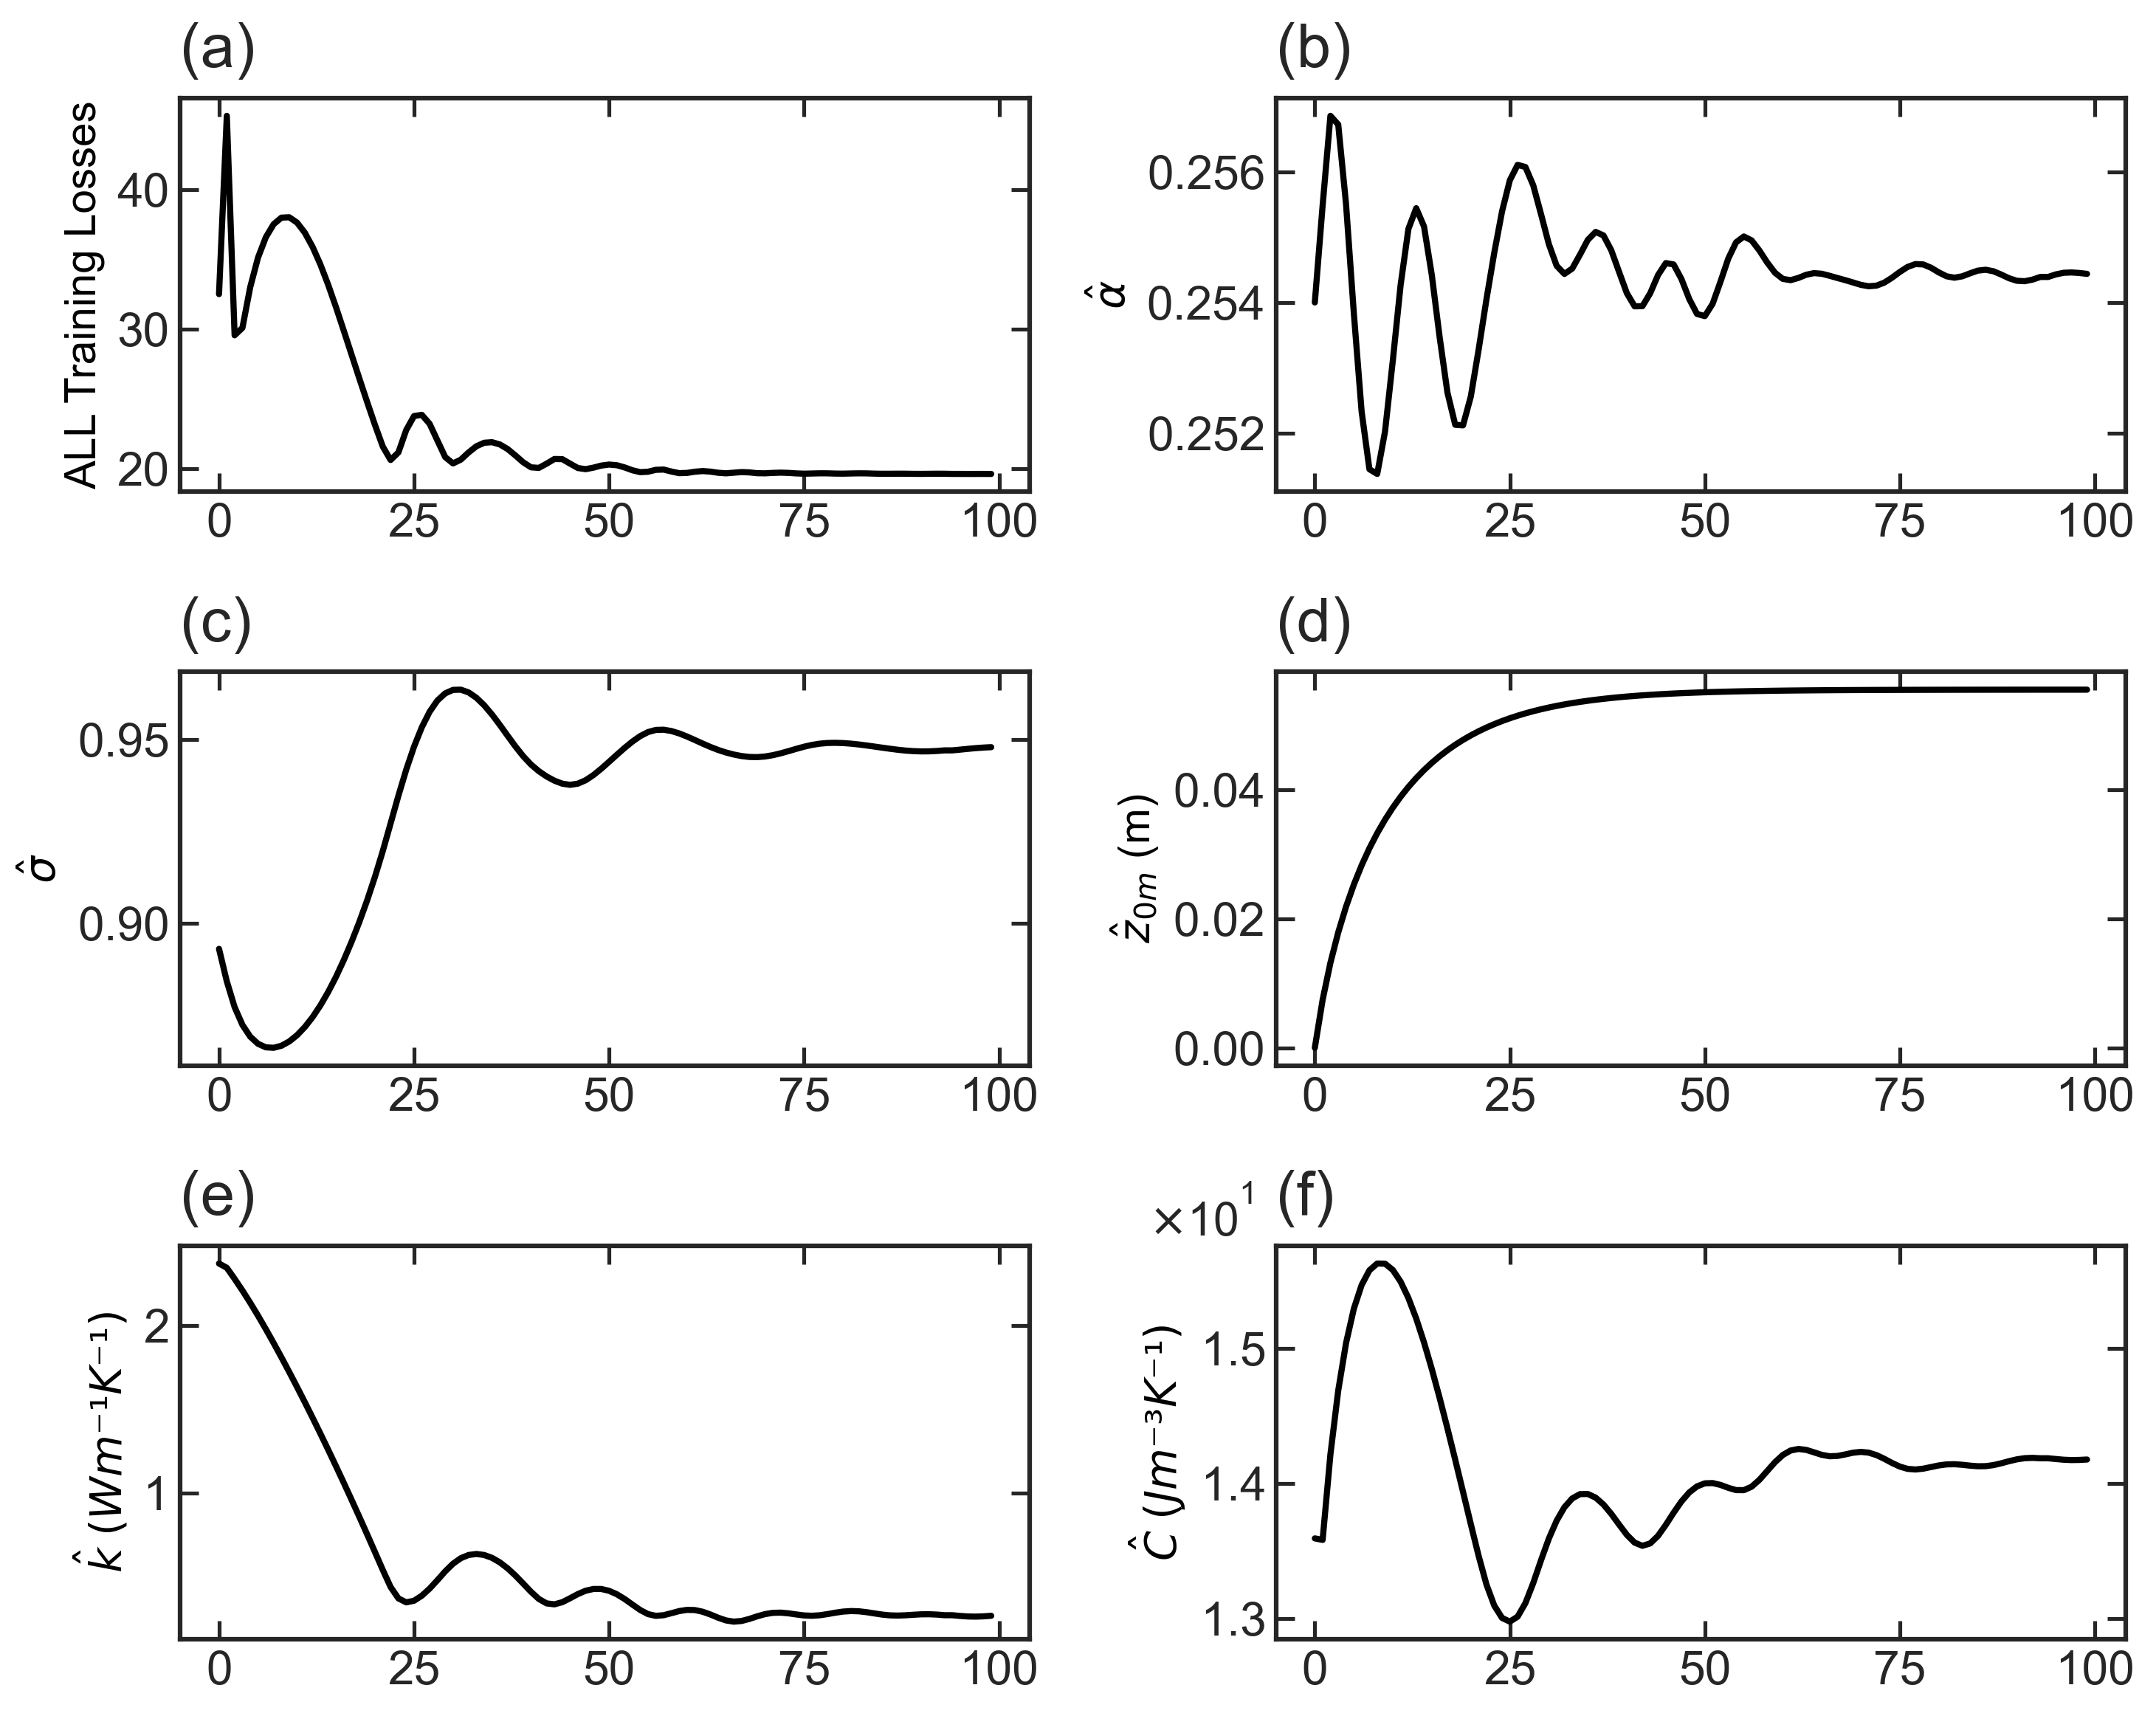

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib import rcParams


def plot_loss_multi(
    data_list, down, up, labels, nums, yranges, sci_flags, row, col, figsize=(10, 8)
):
    plt.style.use("seaborn-v0_8-white")
    rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial"],
            "font.size": 15,
            "axes.linewidth": 1.5,
            "xtick.direction": "in",
            "ytick.direction": "in",
            "xtick.major.size": 6,
            "ytick.major.size": 6,
            "xtick.top": True,
            "ytick.right": True,
            "legend.frameon": False,
            "legend.fontsize": 18,
            "legend.title_fontsize": 20,
            "savefig.dpi": 300,
        }
    )

    # 创建子图
    fig, axes = plt.subplots(row, col, figsize=figsize, dpi=300)
    axes = axes.flatten() if row * col > 1 else [axes]

    x = np.arange(down, up, 1)

    for i, (data, label, num, yrange, sci) in enumerate(
        zip(data_list, labels, nums, yranges, sci_flags)
    ):
        ax = axes[i]

        # 左轴（主轴）
        color1 = "black"
        ax.plot(x, data[down:up], color=color1, linewidth=2, label="C")

        if sci:
            plt.ticklabel_format(
                style="sci", axis="y", scilimits=(-1, 0), useMathText=True
            )
            ax.yaxis.get_offset_text().set_fontsize(15)
            ax.yaxis.get_offset_text().set_position((-0.15, 0.8))

        ax.set_ylabel(label, color=color1)
        # ax.set_yticks(yrange)
        ax.set_title(num, fontsize=20, pad=10, loc="left")

    # 隐藏多余的子图
    for j in range(len(data_list), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"losses.svg", format="svg", dpi=300)
    plt.show()


# 准备数据列表
data_list = [
    T_loss_store,
    alpha_hat_store,
    sigma_hat_store,
    z0m_hat_store,
    k_hat_store,
    C_hat_store,
]

labels = [
    r"ALL Training Losses",
    r"$\hat{\alpha}$",
    r"$\hat{\sigma}$",
    r"$\hat{z}_{0m}$ (m)",
    r"$\hat{k}$ $(W m⁻¹ K⁻¹)$",
    r"$\hat{C}$ $(J m⁻³ K⁻¹)$",
]

nums = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
yranges = [
    np.arange(0, 201, 50),
    np.arange(0.2, 0.231, 0.005),
    np.arange(0.5, 0.99, 0.1),
    np.arange(0, 0.8, 0.1),
    np.arange(0.5, 3.1, 0.5),
    np.arange(1.5e6, 1.7e6, 5e4),
]

sci_flags = [False, False, False, True, False, True]

start = 0
end = len(T_loss_store)

# 调用多子图函数
plot_loss_multi(data_list, start, end, labels, nums, yranges, sci_flags, 3, 2)

In [79]:
path = "/Users/hsc/Paper📑/Submission/paper-2026-lsm-diff-energy/data/2.data_selection/Ejin"
data = pd.read_csv(path + "/meteo_var.csv")
flux = pd.read_csv(path + "/ec_var.csv")
soil_data = pd.read_csv(path + "/soil.csv")
# ------------------------------
Rsd = data["DR"].astype(float).values
Rld = data["DLR_Cor"].astype(float).values
T_atm = data["Ta_5m"].astype(float).values + 273.15
u = flux["Wnd"].astype(float).values
# ------------------------------
meteo_input = np.array([Rsd, Rld, T_atm, u])
# phy_attr = jnp.array([sand, clay, som, gravel])

Train_T = (
    np.array(
        [
            soil_data["Ts_2cm"].astype(float).values,
            soil_data["Ts_4cm"].astype(float).values,
            soil_data["Ts_10cm"].astype(float).values,
            soil_data["Ts_20cm"].astype(float).values,
            # soil_data["Ts_40cm"].astype(float).values,
            # soil_data["Ts_60cm"].astype(float).values,
            # soil_data["Ts_100cm"].astype(float).values,
        ]
    ).T
    + 273.15
)

In [80]:
eb_result = np.load("./EB_result.npy")
T_result = np.load("./T_result.npy")
T_out = np.load(
    "../../Experiments/parameters_optimization_expriments/0.EST/T_result_Ejin.npy"
)
eb_out = np.load(
    "../../Experiments/parameters_optimization_expriments/0.EST/EB_result_Ejin.npy"
)
r_s, r_l, h, Gg = eb_result
c_r_s, c_r_l, c_H, c_G = eb_out

Rsd = data["DR"].astype(float).values
Rld = data["DLR_Cor"].astype(float).values
Rsu = data["UR"].astype(float).values
Rlu = data["ULR_Cor"].astype(float).values
G = -1 * soil_data["Gs_1"].astype(float).values
Hs = flux["Hs"].astype(float).values

Rs = Rsu - Rsd
Rl = Rlu - Rld
Rn = Rsu + Rlu - Rsd - Rld

G6 = -1 * (
    np.array(
        [
            soil_data["Gs_1"].astype(float).values,
            soil_data["Gs_2"].astype(float).values,
            soil_data["Gs_3"].astype(float).values,
        ]
    )
).mean(axis=0)

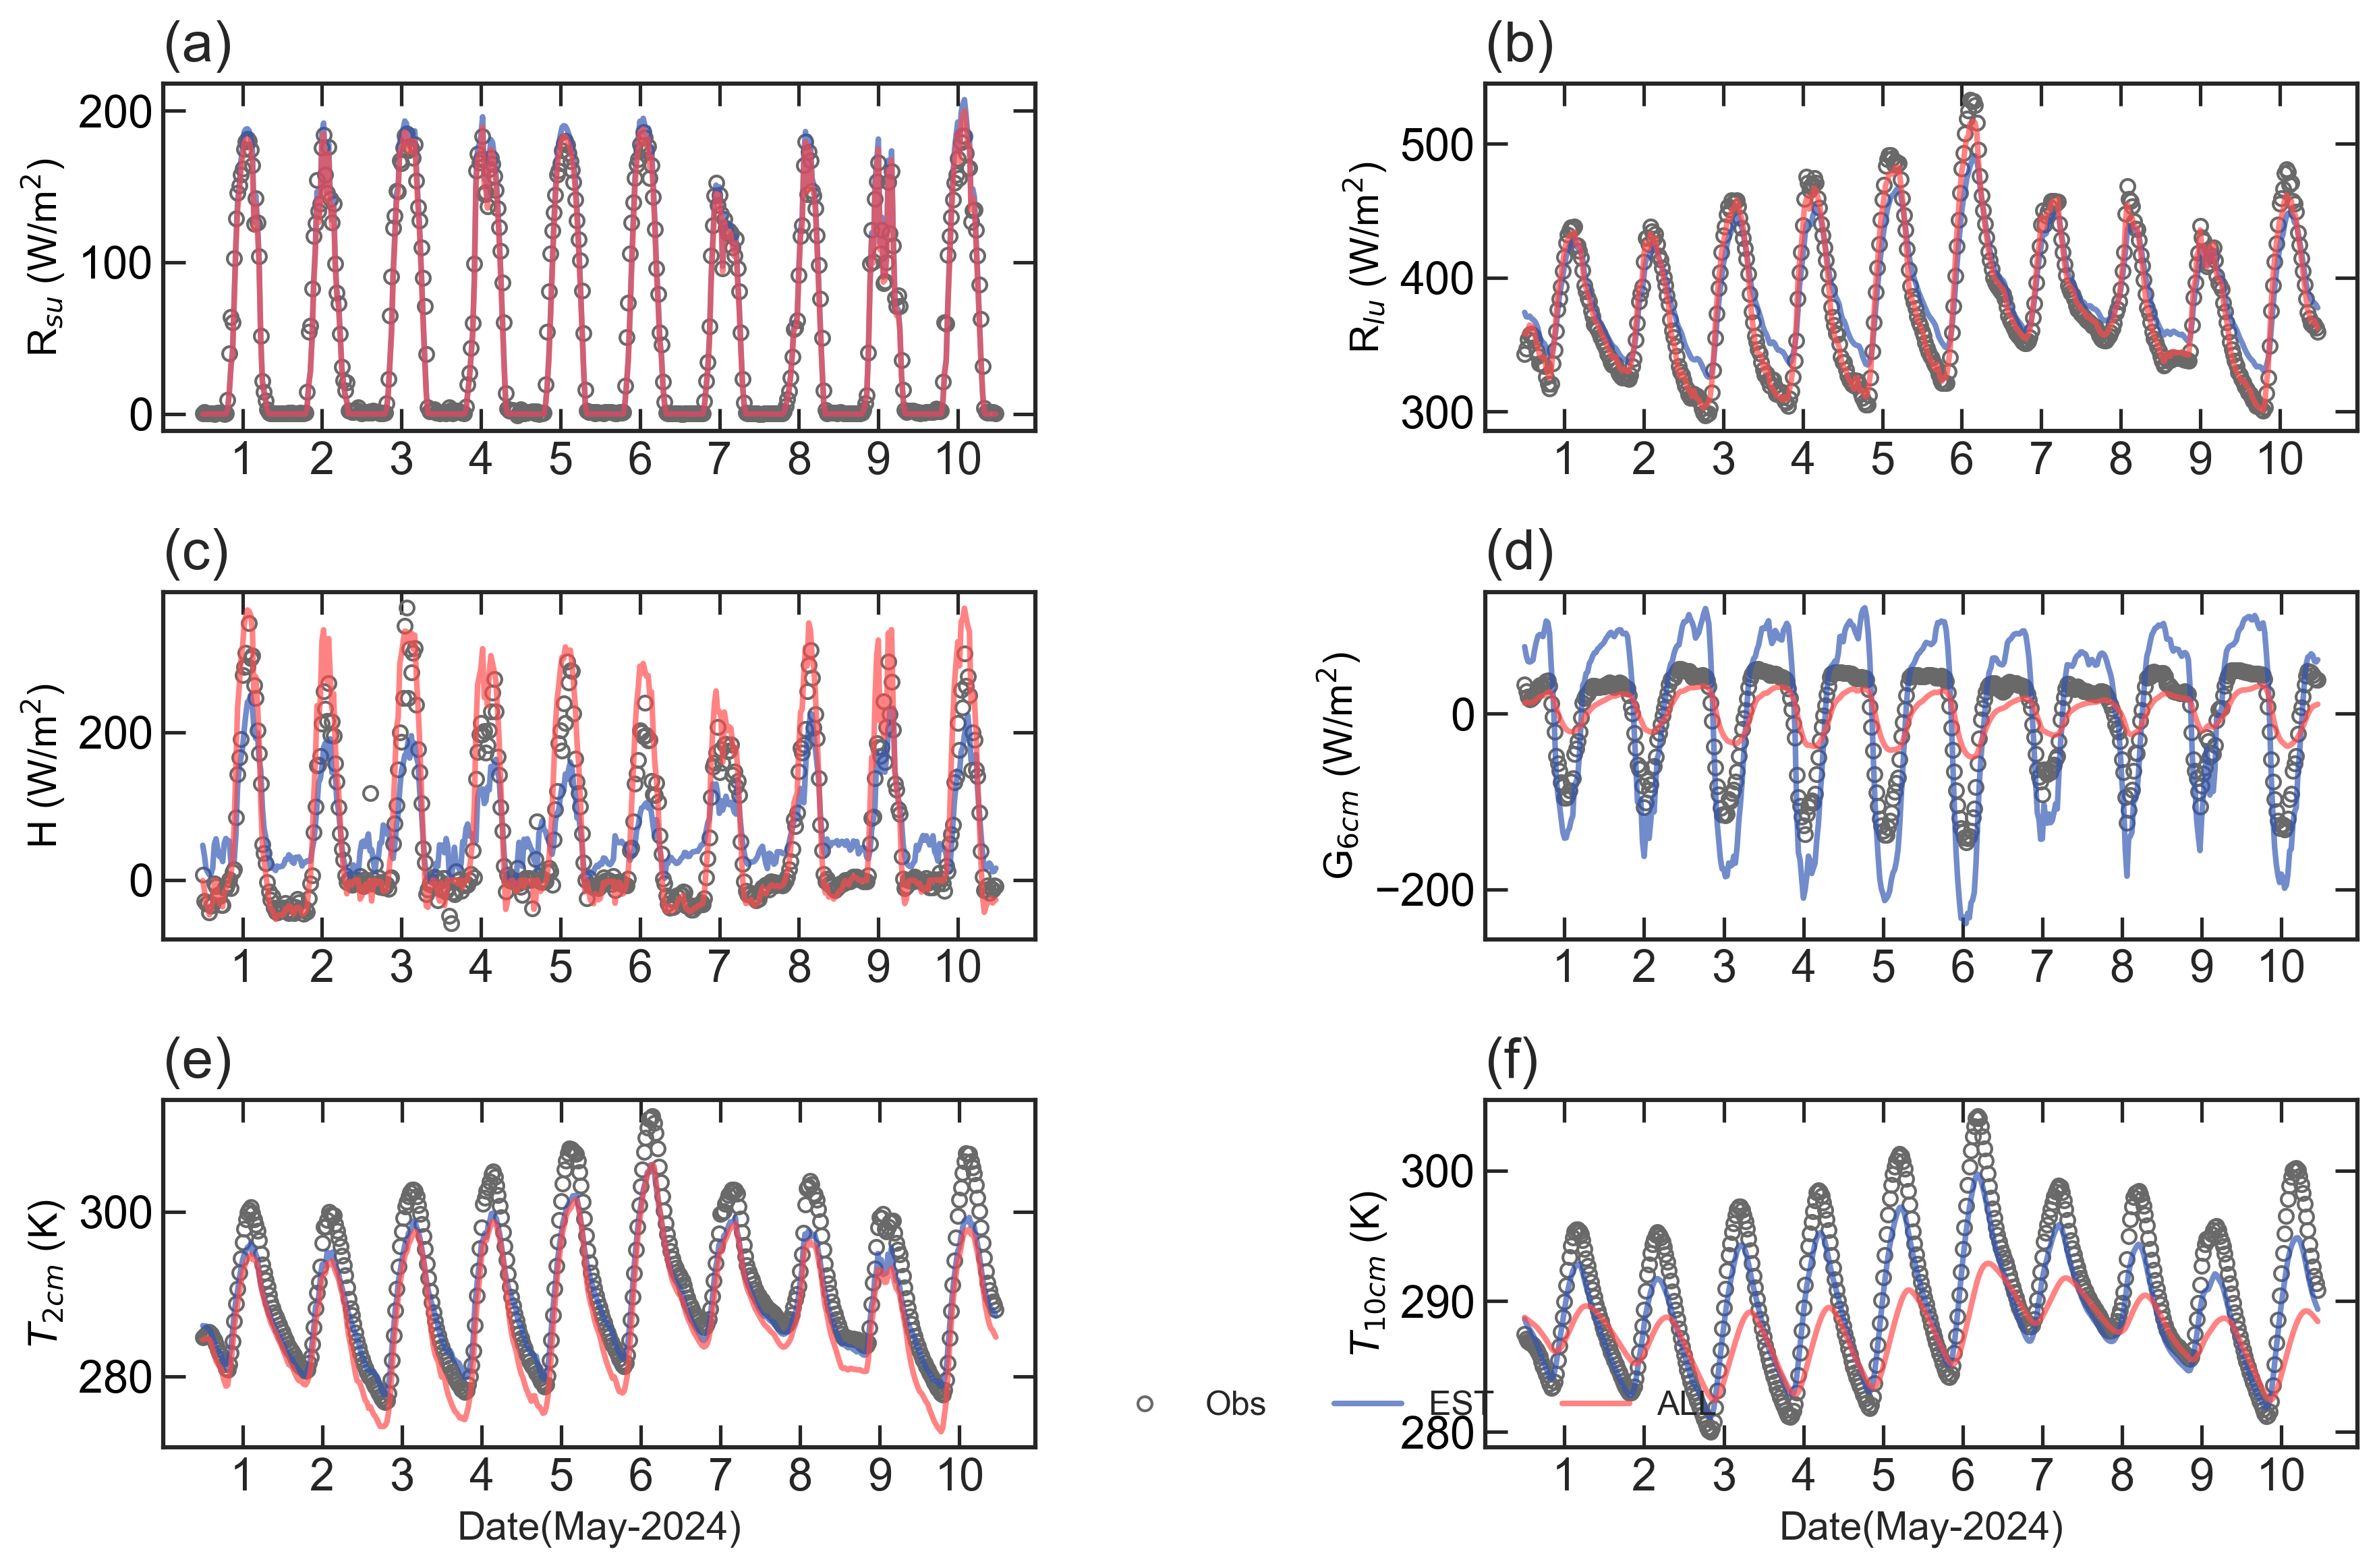

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams


def plot_line_subplot(
    ax, data1, data2, data3, title, ylabel, color_gray, color2, color3
):
    """绘制单个折线子图的通用函数"""
    ax.plot(
        data1,
        color=color_gray,
        marker="o",
        markerfacecolor="none",
        linestyle="None",
        markersize=5,
        label="Obs",
    )
    ax.plot(data3, color=color3, linewidth=2, label="EST")
    ax.plot(data2, color=color2, linewidth=2, label="ALL")

    ax.tick_params(axis="y", labelsize=16, labelcolor="black")
    ax.set_ylabel(ylabel, color="#000000")

    # 统一x轴
    ax.set_xticks(np.arange(1, 11) * 24 * 2 - 24 * 1)
    ax.set_xticklabels(np.arange(1, 11), fontsize=16)
    ax.set_title(title, fontsize=20, loc="left", pad=8)


def combined_line_plots(
    Rsu,
    r_s,
    c_r_s,
    Rlu,
    r_l,
    c_r_l,
    Hs,
    h,
    c_H,
    G6,
    k_hat_store,
    T_result,
    T_out,
    Train_T,
):
    rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial"],
            "font.size": 15,
            "axes.linewidth": 1.5,
            "xtick.direction": "in",
            "ytick.direction": "in",
            "xtick.major.size": 8,
            "ytick.major.size": 8,
            "xtick.top": True,
            "ytick.right": True,
            "legend.frameon": False,
            "legend.fontsize": 12,
            "legend.title_fontsize": 20,
            "savefig.dpi": 300,
        }
    )

    # 定义颜色
    color_gray = "dimgray"
    color2 = "#FF4B4BAF"
    color3 = "#3256B3AF"

    # 创建3行2列的子图
    fig, axes = plt.subplots(3, 2, figsize=(12, 8), dpi=300)
    fig.subplots_adjust(hspace=0.4, wspace=0.3)

    # 定义各子图的信息
    subplot_info = [
        {
            "data1": Rsu,
            "data2": np.array(r_s),
            "data3": c_r_s,
            "title": r"(a)",
            "ylabel": r"R$_{su}$ (W/m${^2}$)",
        },
        {
            "data1": Rlu,
            "data2": np.array(r_l),
            "data3": c_r_l,
            "title": r"(b)",
            "ylabel": r"R$_{lu}$ (W/m${^2}$)",
        },
        {
            "data1": Hs,
            "data2": h,
            "data3": c_H,
            "title": r"(c)",
            "ylabel": r"H (W/m${^2}$)",
        },
        {
            "data1": G6[1:],
            "data2": k_hat_store[-1] * (T_result[1:, 2] - T_result[1:, 1]) / 0.06,
            "data3": 2.4728 * (T_out[1:, 2] - T_out[1:, 1]) / 0.06,
            "title": r"(d)",
            "ylabel": r"G$_{6cm}$ (W/m${^2}$)",
        },
        {
            "data1": Train_T[1:, 0],
            "data2": T_result[1:, 0],
            "data3": T_out[1:, 0],
            "title": r"(e)",
            "ylabel": r"$T_{2cm}$ (K)",
        },
        {
            "data1": Train_T[1:, 2],
            "data2": T_result[1:, 2],
            "data3": T_out[1:, 2],
            "title": r"(f)",
            "ylabel": r"$T_{10cm}$ (K)",
        },
    ]

    # 遍历并绘制每个子图
    for i in range(3):  # 行
        for j in range(2):  # 列
            idx = i * 2 + j  # 计算当前子图索引
            if idx < len(subplot_info):  # 确保不超过子图数量
                current_ax = axes[i, j]
                info = subplot_info[idx]

                plot_line_subplot(
                    current_ax,
                    info["data1"],
                    info["data2"],
                    info["data3"],
                    info["title"],
                    info["ylabel"],
                    color_gray,
                    color2,
                    color3,
                )
                if i == 2:
                    current_ax.set_xlabel("Date(May-2024)")
    current_ax.legend(bbox_to_anchor=(0.3, 0.25), ncol=3, frameon=False)
    # 调整布局
    plt.tight_layout()

    # 保存并显示图形
    plt.savefig("model_output.svg", format="svg", dpi=300)
    plt.show()


combined_line_plots(
    Rsu,
    r_s,
    c_r_s,
    Rlu,
    r_l,
    c_r_l,
    Hs,
    h,
    c_H,
    G6,
    k_hat_store,
    T_result,
    T_out,
    Train_T,
)

In [82]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns


# def zhe_line_map(data1, data2, data3, title, save_title, ylabel):
#     rcParams.update(
#         {
#             "font.family": "sans-serif",
#             "font.sans-serif": ["Arial"],
#             "font.size": 15,
#             "axes.linewidth": 1.5,
#             "xtick.direction": "in",
#             "ytick.direction": "in",
#             "xtick.major.size": 8,
#             "ytick.major.size": 8,
#             "xtick.top": True,
#             "ytick.right": True,
#             "legend.frameon": False,
#             "legend.fontsize": 18,
#             "legend.title_fontsize": 20,
#             "savefig.dpi": 300,
#         }
#     )

#     # 创建图和主坐标轴
#     fig, ax1 = plt.subplots(figsize=(10, 4))
#     # fig.suptitle(title, fontsize=16)

#     # 左轴（主轴）
#     color1 = "dimgray"
#     color2 = "#FF4B4BAF"
#     # color2 = "#000000B0"
#     color3 = "#3256B3AF"
#     ax1.plot(
#         data1,
#         color=color1,
#         marker="o",
#         markerfacecolor="none",
#         linestyle="None",
#         markersize=7,
#         label="Obs",
#     )
#     ax1.plot(data3, color=color3, linewidth=2, label="EST")
#     ax1.plot(data2, color=color2, linewidth=2, label="ALL")

#     # ax1.set_ylim(-200, 700)
#     # ax1.set_yticks(np.arange(-100, 600, 200))
#     ax1.tick_params(axis="y", labelsize=16, labelcolor="black")
#     # ax1.set_ylabel("W/m${^2}$", color="#000000")
#     ax1.set_ylabel(ylabel, color="#000000")

#     # 统一x轴
#     ax1.set_xlabel("Date(May-2024)")
#     ax1.set_xticks(np.arange(1, 11) * 24 * 2 - 24 * 1)
#     ax1.set_xticklabels(np.arange(1, 11), fontsize=16)
#     ax1.set_title(title, fontsize=20, loc="left", pad=8)

#     ax1.legend(bbox_to_anchor=(0.65, 0.98), ncol=3, frameon=False)
#     plt.tight_layout()
#     plt.savefig(save_title, format="svg", dpi=300)
#     plt.show()

In [83]:
# zhe_line_map(Rsu, np.array(r_s), c_r_s, r"(a)", "Rsu.svg", r"R$_{su}$ (W/m${^2}$)")
# zhe_line_map(Rlu, np.array(r_l), c_r_l, r"(b)", "Rlu.svg", r"R$_{lu}$ (W/m${^2}$)")
# zhe_line_map(Hs, h, c_H, r"(c)", "H.svg", r"H (W/m${^2}$)")
# zhe_line_map(
#     G6[1:],
#     k_hat_store[-1] * (T_result[1:, 2] - T_result[1:, 1]) / 0.06,
#     2.71 * (T_out[1:, 2] - T_out[1:, 1]) / 0.06,
#     r"(d)",
#     "G.svg",
#     r"G$_{6cm}$ (W/m${^2}$)",
# )
# zhe_line_map(
#     Train_T[1:, 0], T_result[1:, 0], T_out[1:, 0], r"(e)", "Ts1.svg", r"$T_{2cm}$ (K)"
# )
# zhe_line_map(
#     Train_T[1:, 2], T_result[1:, 2], T_out[1:, 2], r"(f)", "Ts2.svg", r"$T_{10cm}$ (K)"
# )

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def zhe_line_map(data1, data2, data3, data4, title):
    rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial"],
            "font.size": 15,
            "axes.linewidth": 1.5,
            "xtick.direction": "in",
            "ytick.direction": "in",
            "xtick.major.size": 8,
            "ytick.major.size": 8,
            "xtick.top": True,
            "ytick.right": True,
            "legend.frameon": False,
            "legend.fontsize": 18,
            "legend.title_fontsize": 20,
            "savefig.dpi": 300,
        }
    )

    # 创建图和主坐标轴
    fig, ax1 = plt.subplots(figsize=(10, 4))
    # fig.suptitle(title, fontsize=16)

    # 左轴（主轴）
    color1 = "dimgray"
    color2 = "#FF6347"
    color3 = "#3256B3AF"
    ax1.plot(
        data1,
        color=color1,
        marker="o",
        markerfacecolor="none",
        linestyle="None",
        label="Obs",
    )
    ax1.plot(data2, color=color2, linewidth=2, label="")
    ax1.plot(data3, color=color3, linewidth=2, label="")
    ax1.plot(data4, color="black", linestyle="--", linewidth=2, label="Obs(0.06m)")

    # ax1.set_ylim(-200, 700)
    # ax1.set_yticks(np.arange(-100, 600, 200))
    ax1.tick_params(axis="y", labelsize=16, labelcolor="black")
    # ax1.set_ylabel("W/m${^2}$", color=color1)

    # 统一x轴
    ax1.set_ylabel(r"G (W/m${^2}$)", color="#000000")
    ax1.set_xticks(np.arange(1, 11) * 24 * 2 - 24 * 1)
    ax1.set_xticklabels(np.arange(1, 11), fontsize=16)
    ax1.set_title(title, fontsize=20, loc="left", pad=8)
    # ax1.set_yticks(np.arange(0, 800, 50))

    ax1.legend(bbox_to_anchor=(0.55, 0.98), ncol=2, frameon=False)

    plt.tight_layout()
    plt.savefig("G_1.svg", format="svg", dpi=300)
    plt.show()

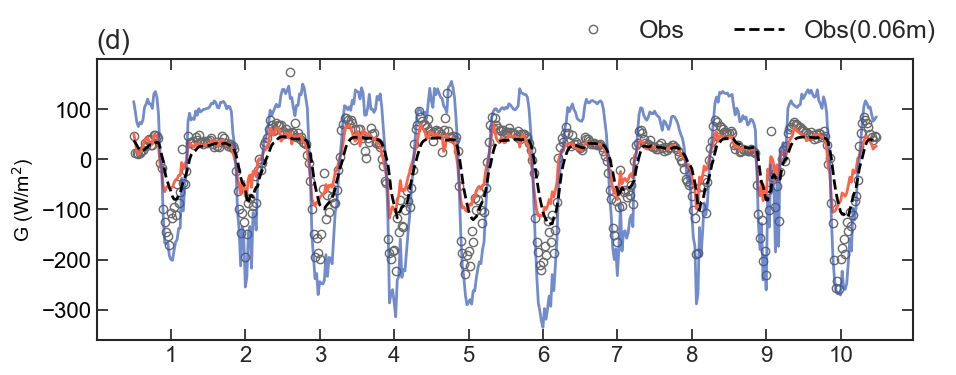

In [85]:
zhe_line_map(Rs + Rl + Hs, Gg, c_G, G, "(d)")

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # 注意：确保引入 np，否则 set_xticks 会报错


def zhe_line_map(data1, data2, data3, title):
    sns.set(style="ticks", font_scale=1.4)
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["axes.linewidth"] = 1.2
    plt.rcParams["axes.labelsize"] = 14
    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"

    # 创建图和主坐标轴
    fig, ax1 = plt.subplots(figsize=(16, 7))
    fig.suptitle(title, fontsize=20)

    # 十六进制颜色定义
    color1 = "#000000"  # black
    color2 = "#696969"  # dimgray
    color3 = "#6495ED"  # 矢车菊蓝
    color4 = "#FF6347"  # 番茄红

    def data_set_ax1(data, color, subti):
        ax1.plot(
            data[:, 0], color=color, linewidth=2, linestyle="-", label=subti + "-2cm"
        )
        ax1.plot(
            data[:, 1], color=color, linewidth=2, linestyle="--", label=subti + "-4cm"
        )
        ax1.plot(
            data[:, 2], color=color, linewidth=2, linestyle="-.", label=subti + "-10cm"
        )
        ax1.plot(
            data[:, 3], color=color, linewidth=3, linestyle=":", label=subti + "-20cm"
        )

    data_set_ax1(data1, color1, "Obv")
    data_set_ax1(data2, color4, "LSM")
    data_set_ax1(data3, color3, "Cali")

    ax1.tick_params(axis="y", labelsize=12, labelcolor=color1)
    ax1.set_ylabel("K", color=color1)

    # 统一x轴
    ax1.set_xlabel("May")
    ax1.set_xticks(np.arange(1, 11) * 24 * 2 - 24 * 1)
    ax1.set_xticklabels(np.arange(1, 11), fontsize=12)
    ax1.set_yticks(np.arange(280, 321, 5))

    sns.despine(right=True)

    ax1.legend(bbox_to_anchor=(0.57, 0.89), ncol=3, frameon=False)
    sns.despine(right=True)

    plt.tight_layout()
    plt.show()


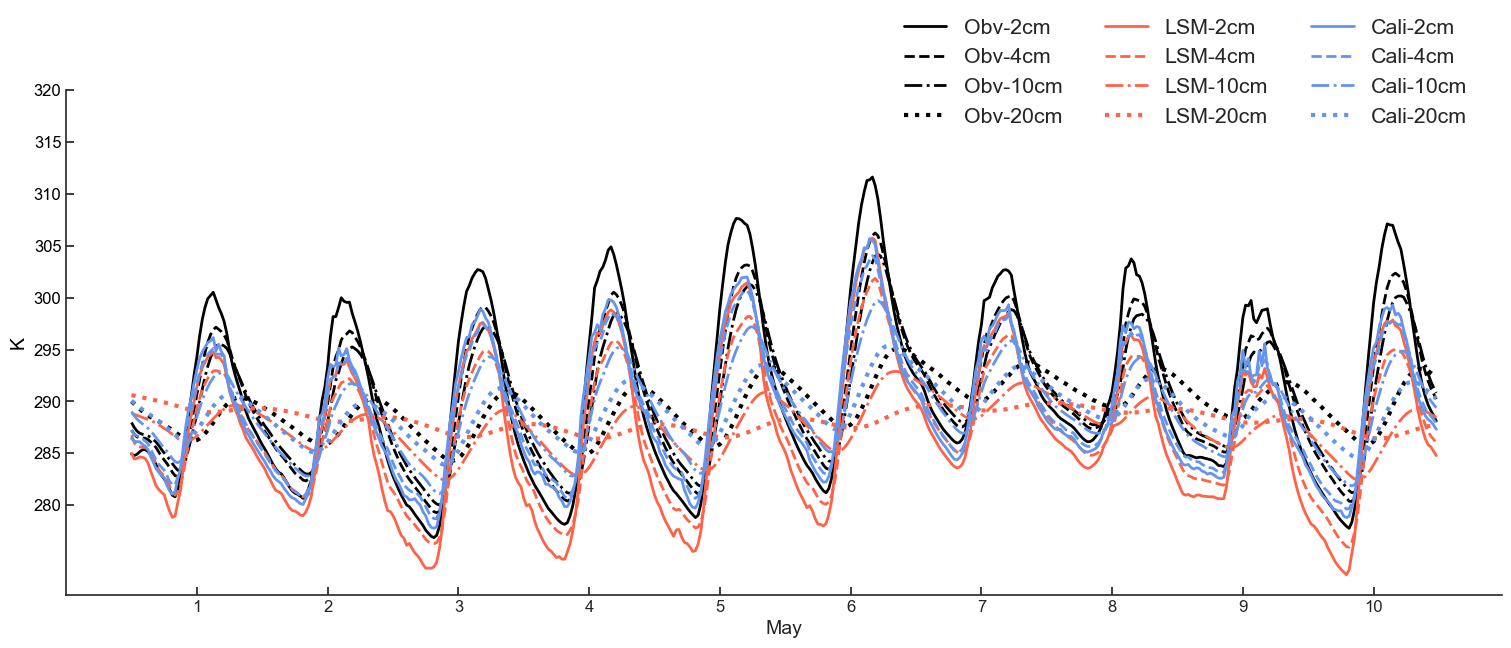

In [87]:
zhe_line_map(Train_T, T_result, T_out, "")

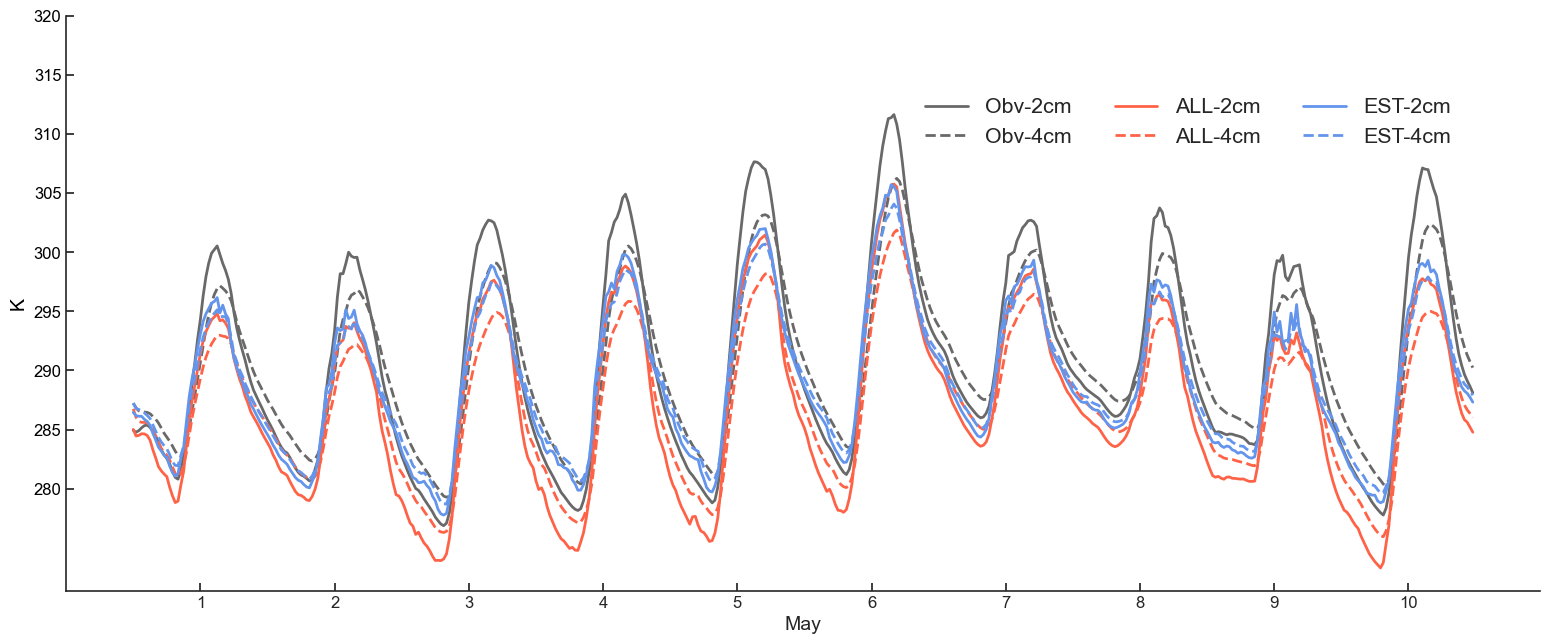

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # 注意：确保引入 np，否则 set_xticks 会报错


def zhe_line_map(data1, data2, data3, title):
    sns.set(style="ticks", font_scale=1.4)
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["axes.linewidth"] = 1.2
    plt.rcParams["axes.labelsize"] = 14
    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"

    # 创建图和主坐标轴
    fig, ax1 = plt.subplots(figsize=(16, 7))
    fig.suptitle(title, fontsize=20)

    # 十六进制颜色定义
    color1 = "#000000"  # black
    color2 = "#696969"  # dimgray
    color3 = "#6495ED"  # 矢车菊蓝
    color4 = "#FF6347"  # 番茄红

    def data_set_ax1(data, color, subti):
        ax1.plot(
            data[:, 0], color=color, linewidth=2, linestyle="-", label=subti + "-2cm"
        )
        ax1.plot(
            data[:, 1], color=color, linewidth=2, linestyle="--", label=subti + "-4cm"
        )
        # ax1.plot(
        #     data[:, 2], color=color, linewidth=2, linestyle="-.", label=subti + "-10cm"
        # )
        # ax1.plot(
        #     data[:, 3], color=color, linewidth=3, linestyle=":", label=subti + "-20cm"
        # )

    data_set_ax1(data1, color2, "Obv")
    data_set_ax1(data2, color4, "ALL")
    data_set_ax1(data3, color3, "EST")

    ax1.tick_params(axis="y", labelsize=12, labelcolor=color1)
    ax1.set_ylabel("K", color=color1)

    # 统一x轴
    ax1.set_xlabel("May")
    ax1.set_xticks(np.arange(1, 11) * 24 * 2 - 24 * 1)
    ax1.set_xticklabels(np.arange(1, 11), fontsize=12)
    ax1.set_yticks(np.arange(280, 321, 5))

    sns.despine(right=True)

    ax1.legend(bbox_to_anchor=(0.57, 0.89), ncol=3, frameon=False)
    sns.despine(right=True)

    plt.tight_layout()
    plt.show()


zhe_line_map(Train_T, T_result, T_out, "")

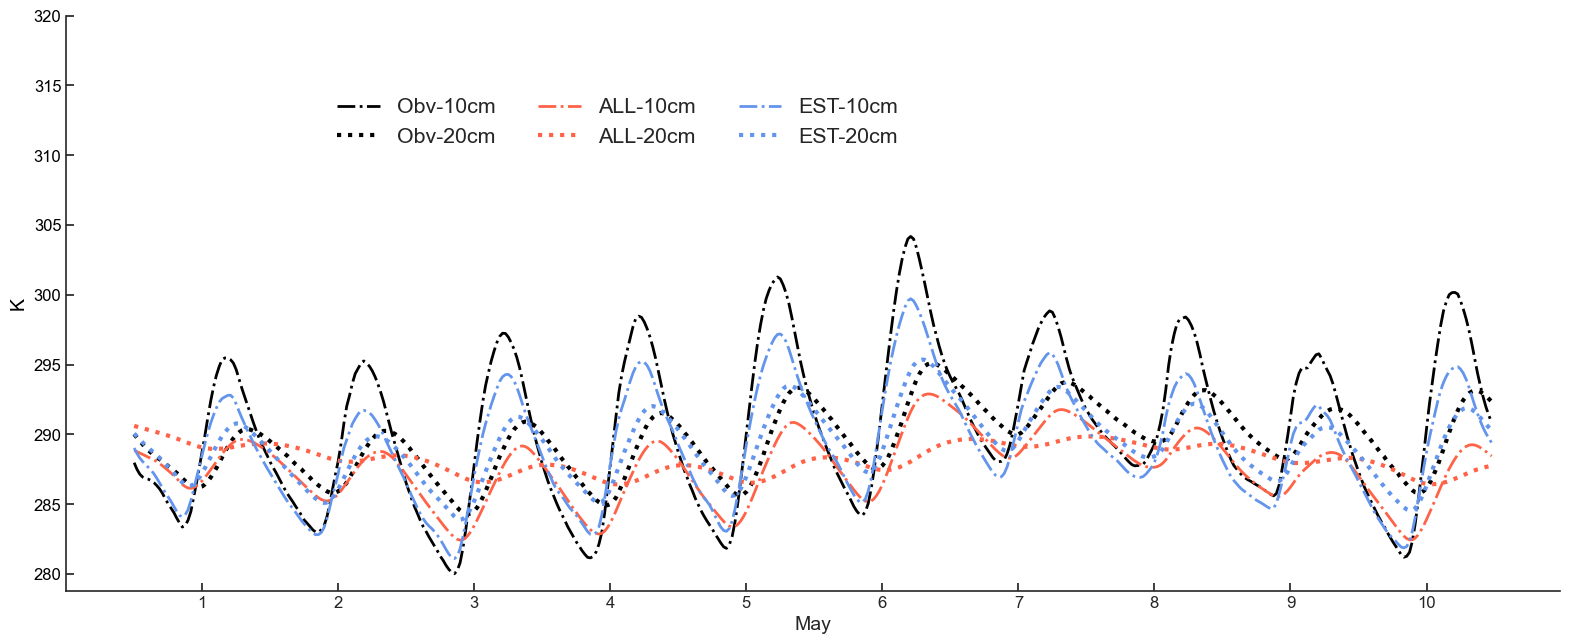

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # 注意：确保引入 np，否则 set_xticks 会报错


def zhe_line_map(data1, data2, data3, title):
    sns.set(style="ticks", font_scale=1.4)
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["axes.linewidth"] = 1.2
    plt.rcParams["axes.labelsize"] = 14
    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"

    # 创建图和主坐标轴
    fig, ax1 = plt.subplots(figsize=(16, 7))
    fig.suptitle(title, fontsize=20)

    # 十六进制颜色定义
    color1 = "#000000"  # black
    color2 = "#696969"  # dimgray
    color3 = "#6495ED"  # 矢车菊蓝
    color4 = "#FF6347"  # 番茄红

    def data_set_ax1(data, color, subti):
        # ax1.plot(
        #     data[:, 0], color=color, linewidth=2, linestyle="-", label=subti + "-2cm"
        # )
        # ax1.plot(
        #     data[:, 1], color=color, linewidth=2, linestyle="--", label=subti + "-4cm"
        # )
        ax1.plot(
            data[:, 2], color=color, linewidth=2, linestyle="-.", label=subti + "-10cm"
        )
        ax1.plot(
            data[:, 3], color=color, linewidth=3, linestyle=":", label=subti + "-20cm"
        )

    data_set_ax1(data1, color1, "Obv")
    data_set_ax1(data2, color4, "ALL")
    data_set_ax1(data3, color3, "EST")

    ax1.tick_params(axis="y", labelsize=12, labelcolor=color1)
    ax1.set_ylabel("K", color=color1)

    # 统一x轴
    ax1.set_xlabel("May")
    ax1.set_xticks(np.arange(1, 11) * 24 * 2 - 24 * 1)
    ax1.set_xticklabels(np.arange(1, 11), fontsize=12)
    ax1.set_yticks(np.arange(280, 321, 5))

    sns.despine(right=True)

    ax1.legend(bbox_to_anchor=(0.57, 0.89), ncol=3, frameon=False)
    sns.despine(right=True)

    plt.tight_layout()
    plt.show()


zhe_line_map(Train_T, T_result, T_out, "")

IndexError: index 4 is out of bounds for axis 1 with size 4

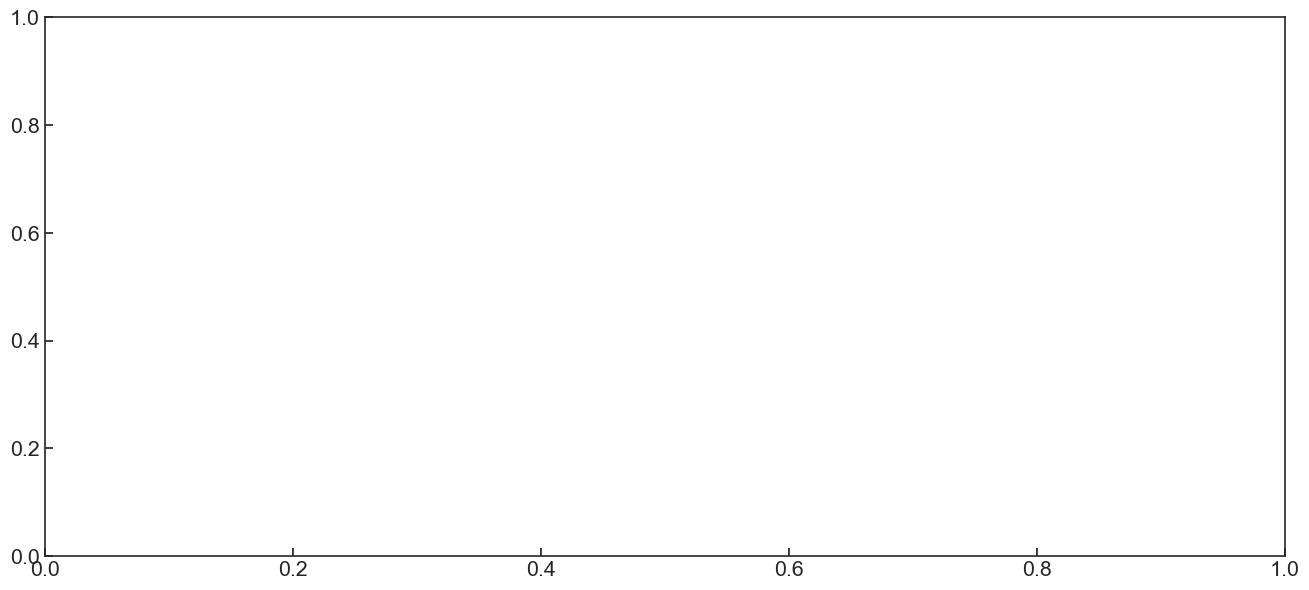

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # 注意：确保引入 np，否则 set_xticks 会报错


def zhe_line_map(data1, data2, data3, title):
    sns.set(style="ticks", font_scale=1.4)
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["axes.linewidth"] = 1.2
    plt.rcParams["axes.labelsize"] = 14
    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"

    # 创建图和主坐标轴
    fig, ax1 = plt.subplots(figsize=(16, 7))
    fig.suptitle(title, fontsize=20)

    # 十六进制颜色定义
    color1 = "#000000"  # black
    color2 = "#696969"  # dimgray
    color3 = "#6495ED"  # 矢车菊蓝
    color4 = "#FF6347"  # 番茄红

    def data_set_ax1(data, color, subti):
        ax1.plot(
            data[:, 4], color=color, linewidth=2, linestyle="-", label=subti + "40cm"
        )
        ax1.plot(
            data[:, 5], color=color, linewidth=2, linestyle="--", label=subti + "60cm"
        )
        ax1.plot(
            data[:, 6], color=color, linewidth=3, linestyle=":", label=subti + "100cm"
        )

    data_set_ax1(data1, color2, "Obv")
    data_set_ax1(data2, color4, "ALL")
    data_set_ax1(data3, color3, "EST")

    ax1.tick_params(axis="y", labelsize=12, labelcolor=color1)
    ax1.set_ylabel("K", color=color1)

    # 统一x轴
    ax1.set_xlabel("May")
    ax1.set_xticks(np.arange(1, 11) * 24 * 2 - 24 * 1)
    ax1.set_xticklabels(np.arange(1, 11), fontsize=12)
    ax1.set_yticks(np.arange(280, 321, 5))

    sns.despine(right=True)

    ax1.legend(bbox_to_anchor=(0.57, 0.89), ncol=3, frameon=False)
    sns.despine(right=True)

    plt.tight_layout()
    plt.show()


zhe_line_map(Train_T, T_result, T_out, "")

In [ ]:
Train_T.shape

In [ ]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))


def corr(a, b):
    return np.corrcoef(a, b)[0, 1]


def caculate_r_c(eb_result, T_result):
    r_s, r_l, h, Gg = eb_result
    t1 = T_result[:, 0]
    t2 = T_result[:, 1]
    # return np.array([rmse(Rsu, r_s), rmse(Rlu, r_l), rmse(Hs, h), rmse(Gg,G),rmse(T_1, t1), rmse(T_2, t2),
    #                 corr(Rsu, r_s), corr(Rlu, r_l), corr(Hs, h), corr(Gg,G),corr(T_1, t1), corr(T_2, t2)])
    print("============  RMSE  ===============")
    print(
        f"{rmse(Rsu, r_s):.2f}, {rmse(Rlu, r_l):.2f}, {rmse(Hs, h):.2f}, {rmse(Gg,G):.2f}, {rmse(Train_T[:,0], t1):.2f}, {rmse(Train_T[:,1], t2):.2f}"
    )
    print("============  Corr  ===============")
    print(
        f"{corr(Rsu, r_s):.3f}, {corr(Rlu, r_l):.3f}, {corr(Hs, h):.3f}, {corr(Gg,G):.3f}, {corr(Train_T[:,0], t1):.3f}, {corr(Train_T[:,1], t2):.3f}"
    )
    print("———————————————————————————————————")

In [ ]:
caculate_r_c(eb_result, T_result)

In [ ]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))


def corr(a, b):
    return np.corrcoef(a, b)[0, 1]


def caculate_r_c(eb_result, T_result):
    r_s, r_l, h, Gg = eb_result
    t1 = T_result[:, 0]
    t2 = T_result[:, 1]
    return np.array(
        [
            rmse(Rsu, r_s),
            rmse(Rlu, r_l),
            rmse(Hs, h),
            rmse(Gg, G),
            rmse(Train_T[1:, 0], t1),
            rmse(Train_T[1:, 1], t2),
            corr(Rsu, r_s),
            corr(Rlu, r_l),
            corr(Hs, h),
            corr(Gg, G),
            corr(Train_T[1:, 0], t1),
            corr(Train_T[1:, 1], t2),
        ]
    )

In [ ]:
# a = np.array([])
# for i in range(1,17):
#     eb_a = np.load(f'/Users/hsc/Desktop/supporting information data/energy balance output/{i}.npy')
#     T_a = np.load(f'/Users/hsc/Desktop/supporting information data/energy balance output/soil temperature/{i}.npy')
#     a = np.concatenate([a,caculate_r_c(eb_a,T_a)])
# pd.DataFrame(a.reshape(-1,12)).to_csv(f'/Users/hsc/Desktop/table_s1.csv')